In [1]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape

(200, 5)

In [3]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


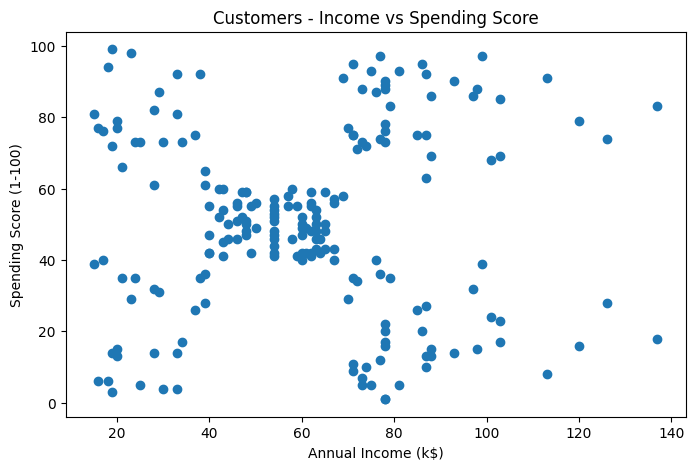

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers - Income vs Spending Score")

plt.show()

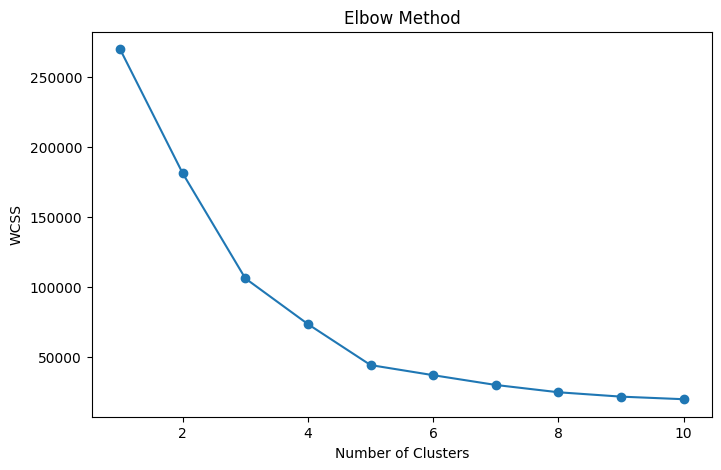

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

X["Cluster"] = kmeans.fit_predict(X)

X.head()

/tmp/ipykernel_3919/862351851.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"] = kmeans.fit_predict(X)


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4


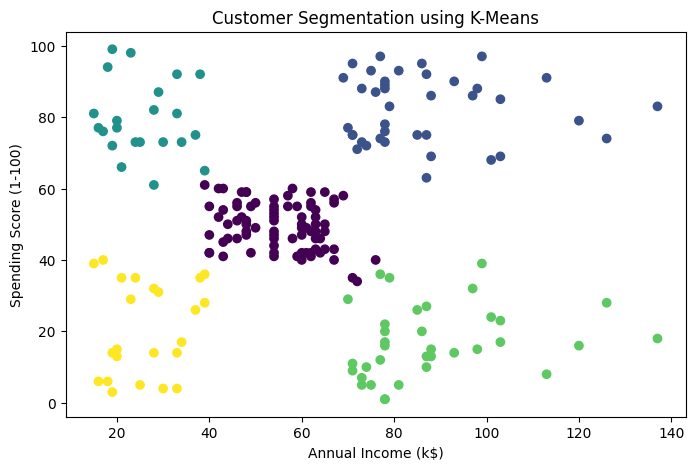

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=X["Cluster"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [11]:
X["Cluster"].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [12]:
X.groupby("Cluster").mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


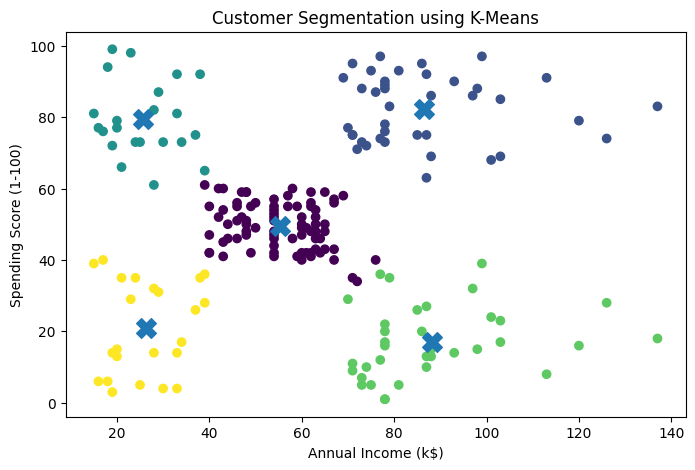

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=X["Cluster"]
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker="X"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [16]:
df["Cluster"] = X["Cluster"]

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [18]:
df.to_csv("customer_segments.csv", index=False)

In [19]:
cluster_names = {
    0: "Average Customers",
    1: "High Value Customers",
    2: "High Spending Low Income",
    3: "High Income Low Spending",
    4: "Low Value Customers"
}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

df[["CustomerID", "Annual Income (k$)", "Spending Score (1-100)", "Customer_Segment"]].head()

,CustomerID,Annual Income (k$),Spending Score (1-100),Customer_Segment
0,1,15,39,Low Value Customers
1,2,15,81,High Spending Low Income
2,3,16,6,Low Value Customers
3,4,16,77,High Spending Low Income
4,5,17,40,Low Value Customers


In [20]:
df.to_csv("customer_segments.csv", index=False)